In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [ ]:
import seaborn as sns

data = sns.load_dataset("geyser")

print(data.head())

   duration  waiting   kind
0     3.600       79   long
1     1.800       54  short
2     3.333       74   long
3     2.283       62  short
4     4.533       85   long


In [ ]:
X = data[['waiting', 'duration']]

print(X.head())

   waiting  duration
0       79     3.600
1       54     1.800
2       74     3.333
3       62     2.283
4       85     4.533


In [ ]:
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

data['Cluster'] = kmeans.fit_predict(X)

In [ ]:
print(data[['waiting', 'duration', 'Cluster']].head(10))

   waiting  duration  Cluster
0       79     3.600        0
1       54     1.800        1
2       74     3.333        0
3       62     2.283        1
4       85     4.533        0
5       55     2.883        1
6       88     4.700        0
7       85     3.600        0
8       51     1.950        1
9       85     4.350        0


In [ ]:
print("Cluster Centers:")
print(kmeans.cluster_centers_)

Cluster Centers:
[[80.28488372  4.29793023]
 [54.75        2.09433   ]]


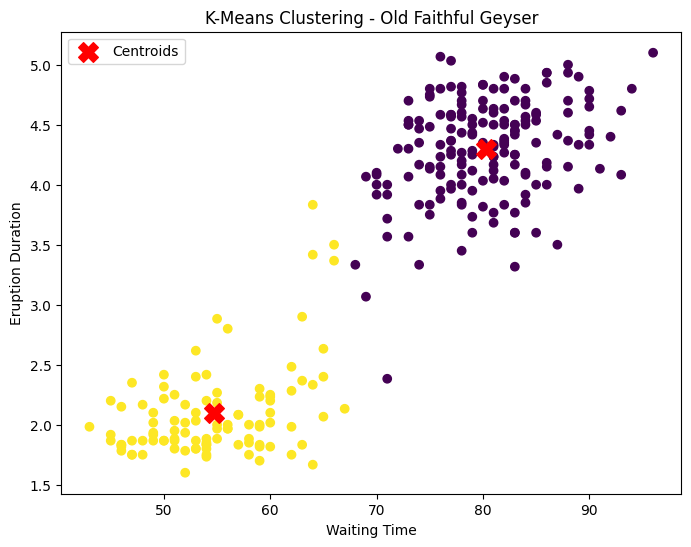

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(
    data['waiting'],
    data['duration'],
    c=data['Cluster'],
    cmap='viridis'
)

plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    color='red',
    marker='X',
    s=200,
    label='Centroids'
)

plt.xlabel("Waiting Time")
plt.ylabel("Eruption Duration")
plt.title("K-Means Clustering - Old Faithful Geyser")
plt.legend()
plt.show()